# Augmentation visualization

Compare one `mini_train` sample before and after the two training augmentations:

- **Photometric:** only the image changes
- **Horizontal flip:** image, boxes, radar `u`, and `vy_comp` must stay aligned

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from matplotlib.patches import Rectangle

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.augmentation import SynchronizedAugmentation
from src.config import load_config
from src.data_loader.nuscenes_front_loader import NuScenesFrontLoader
from src.utils import resolve_path

plt.style.use("seaborn-v0_8-whitegrid")
torch.manual_seed(42)

config = load_config()
dataset = NuScenesFrontLoader(
    dataroot=resolve_path(config["train"]["dataroot"]),
    split=config["train"].get("split", "mini_train"),
    image_size=config["image_size"],
    radar_channels=tuple(config["radar"]["channels"]),
    nsweeps=config["radar"]["nsweeps"],
    camera_channel=config["camera_channel"],
    class_name=config["class_name"],
    augmentation=None,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Train samples: {len(dataset)}")


Project root: /Users/williamkuo/Desktop/imec
Train samples: 323


In [2]:
def find_sample_with_boxes_and_radar(dataset, start_index=0):
    for index in range(start_index, len(dataset)):
        sample = dataset[index]
        if len(sample["target"]["boxes"]) == 0:
            continue
        if len(sample["radar_points"]) == 0:
            continue
        return index, sample
    raise RuntimeError("No sample with both pedestrian boxes and radar points was found.")


def show_sample(axis, image, boxes, radar_points, title):
    axis.imshow(image.detach().cpu().clamp(0.0, 1.0).permute(1, 2, 0).numpy())
    axis.set_title(title)
    axis.axis("off")

    for box in boxes.detach().cpu():
        x1, y1, x2, y2 = box.tolist()
        axis.add_patch(
            Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                edgecolor="red",
                linewidth=2.0,
            )
        )

    if len(radar_points) == 0:
        return

    radar = radar_points.detach().cpu()
    u = radar[:, 0]
    v = radar[:, 1]
    vy_comp = radar[:, 5]
    axis.scatter(u, v, s=12, c="cyan", edgecolors="black", linewidths=0.3, zorder=3)
    # +vy_comp is left in the RADAR_FRONT frame, which is -u in the image.
    axis.quiver(
        u,
        v,
        -vy_comp,
        torch.zeros_like(vy_comp),
        angles="xy",
        scale_units="xy",
        scale=0.15,
        color="yellow",
        width=0.004,
        zorder=4,
    )


SAMPLE_INDEX = None  # set an int to pin one sample, or leave None to auto-pick

if SAMPLE_INDEX is None:
    SAMPLE_INDEX, sample = find_sample_with_boxes_and_radar(dataset)
else:
    sample = dataset[SAMPLE_INDEX]

original_image = sample["image"].clone()
original_boxes = sample["target"]["boxes"].clone()
original_radar = sample["radar_points"].clone()

print(f"Sample index: {SAMPLE_INDEX}")
print(f"Scene: {sample['metadata']['scene_name']}")
print(f"Pedestrian boxes: {len(original_boxes)}")
print(f"Radar points: {len(original_radar)}")


Sample index: 0
Scene: scene-0061
Pedestrian boxes: 17
Radar points: 61


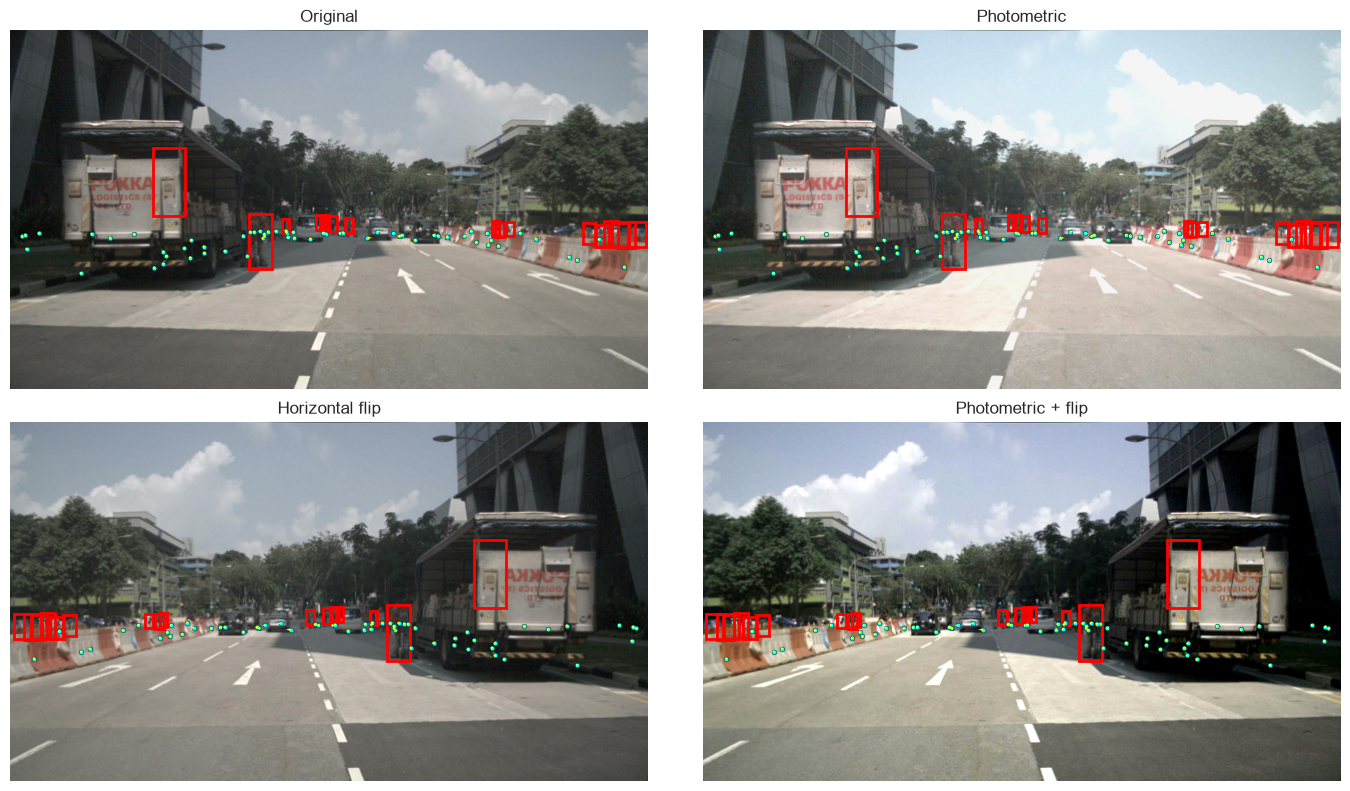

In [3]:
photometric = SynchronizedAugmentation(
    image_size=config["image_size"],
    photometric={
        "enabled": True,
        "brightness": 0.4,
        "contrast": 0.4,
        "saturation": 0.4,
        "hue": 0.05,
    },
    horizontal_flip={"enabled": False},
)
horizontal_flip = SynchronizedAugmentation(
    image_size=config["image_size"],
    photometric={"enabled": False},
    horizontal_flip={"enabled": True, "probability": 1.0},
)
both = SynchronizedAugmentation(
    image_size=config["image_size"],
    photometric={
        "enabled": True,
        "brightness": 0.4,
        "contrast": 0.4,
        "saturation": 0.4,
        "hue": 0.05,
    },
    horizontal_flip={"enabled": True, "probability": 1.0},
)

photo_image, photo_boxes, photo_radar = photometric(
    original_image.clone(),
    original_boxes.clone(),
    original_radar.clone(),
)
flip_image, flip_boxes, flip_radar = horizontal_flip(
    original_image.clone(),
    original_boxes.clone(),
    original_radar.clone(),
)
both_image, both_boxes, both_radar = both(
    original_image.clone(),
    original_boxes.clone(),
    original_radar.clone(),
)

figure, axes = plt.subplots(2, 2, figsize=(14, 8))
show_sample(axes[0, 0], original_image, original_boxes, original_radar, "Original")
show_sample(axes[0, 1], photo_image, photo_boxes, photo_radar, "Photometric")
show_sample(axes[1, 0], flip_image, flip_boxes, flip_radar, "Horizontal flip")
show_sample(axes[1, 1], both_image, both_boxes, both_radar, "Photometric + flip")
figure.tight_layout()
plt.show()
